[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/maryrobynbernabe/step3-coral-project-testing-mobilenetv2)

# Load a saved model
Please change the path value below

In [1]:
import tensorflow as tf
#path of the saved model
loaded_model = tf.keras.models.load_model('/kaggle/input/notebooks/maryrobynbernabe/step2-coral-project-mobilenetv2-training/MobileNetV2_epochs_5_learning_rate_0.001.h5')

2026-06-03 01:05:39.386542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780448739.564615      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780448739.616816      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780448740.006721      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780448740.006756      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780448740.006759      23 computation_placer.cc:177] computation placer alr

# Test Images Path

In [2]:
# Provide the test path to the folder
src_folder = "/kaggle/input/notebooks/maryrobynbernabe/step1-coral-project-dataset-splitting/test"

# Dictionary of the labels predicted by the model


In [3]:
import os

#predicted labels
dict_labels = [file for file in os.listdir(src_folder) if os.path.isdir(os.path.join(src_folder, file))]
dict_labels.sort()
dict_labels = dict(enumerate(dict_labels))
print(dict_labels)

{0: 'bleached_corals', 1: 'healthy_corals'}


# Create a list of the images in the test and train folders

In [4]:
import os
directory_contents = []
# Find all subfolders in the source folder src_folder
for index in range(0,len(dict_labels)):
  directory_contents.append(dict_labels[index])
print(directory_contents)

# List the files in each subfolder
list_files = []
# Find all the files
for folder_name in directory_contents:
  files_list = os.listdir(os.path.join(src_folder, folder_name))
  list_files.append(files_list)
print(list_files)

['bleached_corals', 'healthy_corals']
[['23153468189_c2eddee896_o.jpg', '14973513881_ae1efe9e2a_b.jpg', '11263772193_b910d0037b_o.jpg', '27066547605_be56102690_o.jpg', '4559842029_e37966b82f_o.jpg', '14633934787_b2a1e4e803_o.jpg', '14948757477_ec668ebe8d_o.jpg', '7215191230_980c8f0bc4_o.jpg', '33588528200_d7d7a82ba1_o.jpg', '28497428126_855134e3a1_o.jpg', '3026218663_aafea2df30_o.jpg', '1257640480_faad6caad9_o.jpg', '28451693571_cfbf73acbb_o.jpg', '15890087590_4dbddacb5b_o.jpg', '3117331288_862bc308cb_o.jpg', '6398049615_c4626706d9_o.jpg', '18202562962_3aaed30f4c_o.jpg', '21210061359_7dbeee3e98_o.jpg', '8727090033_c3b2073e44_o.jpg', '5529485045_0e83ba0976_b.jpg', '28245768540_96e6446e1a_o.jpg', '13754287985_5fc707aced_o.jpg', '9312549083_7e8afa3e10_o.jpg', '33129932334_7355a3ec15_o.jpg', '21386078352_33197739f0_o.jpg', '33973839505_218cd7cd11_o.jpg', '41658717240_0f44c1bd2d_o.jpg', '5397426883_1bc9b131a9_o.jpg', '33588597750_8e47385004_o.jpg', '26029050502_5c8f6db02d_o.jpg', '147899048

# Create the predictions and label lists

In [5]:
from keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
# A counter to increment after processing each categoty
category_count = 0
# label list
label = []
# Prediction list
predictions = []
y_score = []
for categories in list_files:
  # Create the labels while iterating over each category
  label_temp = np.ones((len(categories))).astype(int)*category_count
  print(label_temp)
  # Add it to existing labels
  label.extend(label_temp)
  for file_name in categories:
    # test image file
    img_path = src_folder + '/' + directory_contents[category_count] + '/' + file_name
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)
    prediction = loaded_model.predict(img_preprocessed)
    y_score.append(prediction)
    # Save the index of maximum probability
    predictions.append(np.argmax(prediction))
  category_count += 1


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


I0000 00:00:1780448757.627883      71 service.cc:152] XLA service 0x7aa440004170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780448757.627972      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780448757.627980      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780448758.250165      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780448767.239875      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

### ROC Curve

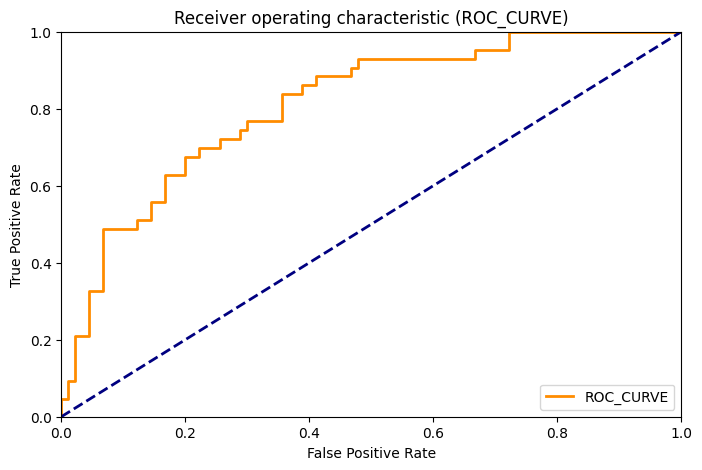

In [6]:
probs = np.array([i[0] for i in y_score])
#ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
# 0s are negative and 1s are positive
fpr, tpr, _ = roc_curve(label, probs[:,1])

plt.figure(figsize = (8,5))
plt.plot(fpr,tpr, label = "ROC_CURVE", lw = 2, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic (ROC_CURVE)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.00])
plt.legend(loc = 'lower right')
plt.show()

# Confusion Matrix

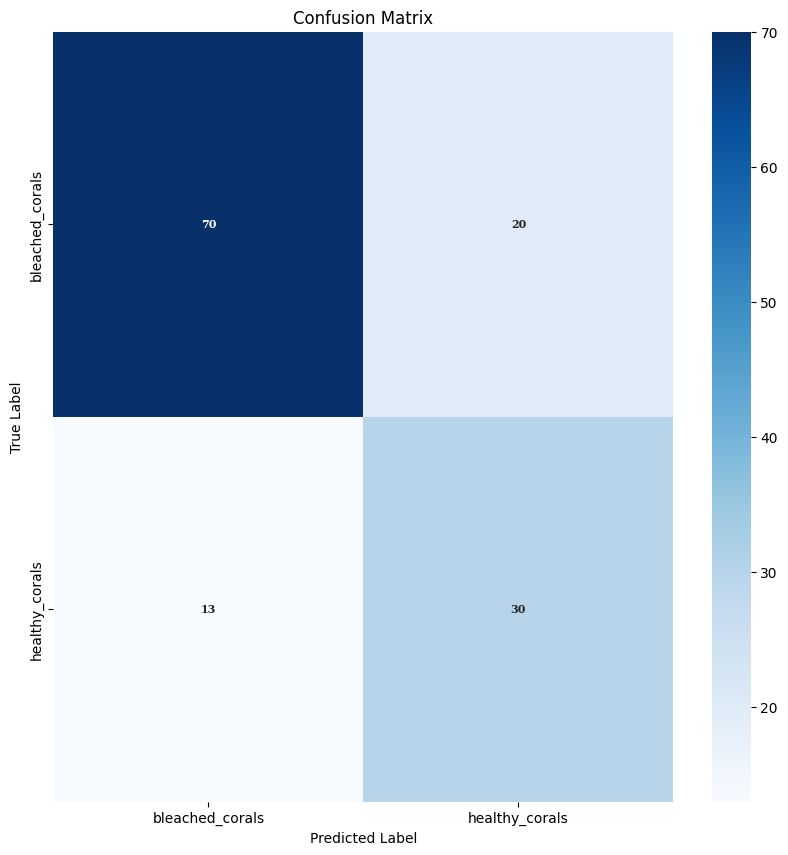

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
display_labels = sorted(directory_contents)
plt.figure(figsize = (10,10))
sns.heatmap(confusion_matrix(label,predictions),
            annot = True,
            fmt = 'g',
            cmap = "Blues",
            xticklabels=display_labels,
            yticklabels = display_labels,
            annot_kws={
                'fontsize': 8,
                'fontweight': 'bold',
                'fontfamily': 'serif'
            })
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
#ConfusionMatrixDisplay.from_predictions(label, predictions, display_labels=display_labels, cmap="binary")
plt.show()

# Classification Report

In [8]:
#classification reports
from sklearn.metrics import classification_report
print(classification_report(label,predictions))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81        90
           1       0.60      0.70      0.65        43

    accuracy                           0.75       133
   macro avg       0.72      0.74      0.73       133
weighted avg       0.76      0.75      0.76       133

